#  Car Price Prediction

In [453]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [454]:
car_df = pd.read_csv("Car_details_v3.csv")

In [455]:
car_df.head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
5,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14 kmpl,1197 CC,81.86 bhp,113.75nm@ 4000rpm,5.0
6,Maruti Wagon R LXI DUO BSIII,2007,96000,175000,LPG,Individual,Manual,First Owner,17.3 km/kg,1061 CC,57.5 bhp,"7.8@ 4,500(kgm@ rpm)",5.0
7,Maruti 800 DX BSII,2001,45000,5000,Petrol,Individual,Manual,Second Owner,16.1 kmpl,796 CC,37 bhp,59Nm@ 2500rpm,4.0
8,Toyota Etios VXD,2011,350000,90000,Diesel,Individual,Manual,First Owner,23.59 kmpl,1364 CC,67.1 bhp,170Nm@ 1800-2400rpm,5.0
9,Ford Figo Diesel Celebration Edition,2013,200000,169000,Diesel,Individual,Manual,First Owner,20.0 kmpl,1399 CC,68.1 bhp,160Nm@ 2000rpm,5.0


In [456]:
print(car_df.columns.tolist())
print(car_df.shape)

['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats']
(8128, 13)


In [457]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [458]:
# To check for missing values in the dataset
car_df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [459]:
# To drop the missing values from the dataset
car_df= car_df.dropna().copy()
car_df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


In [460]:
# To check the number of duplicate rows in the dataset
car_Duplicates = car_df.duplicated().sum()
car_Duplicates

np.int64(1189)

In [461]:
# To drop the duplicate rows from the dataset
car_df = car_df.drop_duplicates()
car_df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8121,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,Petrol,Individual,Manual,Second Owner,18.9 kmpl,998 CC,67.1 bhp,90Nm@ 3500rpm,5.0
8122,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,Diesel,Individual,Manual,Second Owner,22.54 kmpl,1396 CC,88.73 bhp,219.7Nm@ 1500-2750rpm,5.0
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0


In [462]:
car_Duplicates = car_df.duplicated().sum()
car_Duplicates

np.int64(0)

In [463]:
# using .loc whenever we want to modify a column in the dataframe
car_df.loc[:, 'fuel'] = car_df['fuel'].str.lower().str.strip()
car_df = car_df.copy()
car_df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8121,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,petrol,Individual,Manual,Second Owner,18.9 kmpl,998 CC,67.1 bhp,90Nm@ 3500rpm,5.0
8122,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,diesel,Individual,Manual,Second Owner,22.54 kmpl,1396 CC,88.73 bhp,219.7Nm@ 1500-2750rpm,5.0
8123,Hyundai i20 Magna,2013,320000,110000,petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0


In [464]:
# Car Age 
car_df.loc[:, "car_age"] = 2026 - car_df["year"]
car_df = car_df.copy()
car_df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,car_age
0,Maruti Swift Dzire VDI,2014,450000,145500,diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0,12
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0,12
2,Honda City 2017-2020 EXi,2006,158000,140000,petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0,20
3,Hyundai i20 Sportz Diesel,2010,225000,127000,diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0,16
4,Maruti Swift VXI BSIII,2007,130000,120000,petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8121,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,petrol,Individual,Manual,Second Owner,18.9 kmpl,998 CC,67.1 bhp,90Nm@ 3500rpm,5.0,13
8122,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,diesel,Individual,Manual,Second Owner,22.54 kmpl,1396 CC,88.73 bhp,219.7Nm@ 1500-2750rpm,5.0,12
8123,Hyundai i20 Magna,2013,320000,110000,petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0,13
8124,Hyundai Verna CRDi SX,2007,135000,119000,diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0,19


In [465]:
# Extracting brand 
car_df.loc[:,'brand'] = car_df['name'].str.split().str[0]
car_df = car_df.copy()
car_df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,car_age,brand
0,Maruti Swift Dzire VDI,2014,450000,145500,diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0,12,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0,12,Skoda
2,Honda City 2017-2020 EXi,2006,158000,140000,petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0,20,Honda
3,Hyundai i20 Sportz Diesel,2010,225000,127000,diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0,16,Hyundai
4,Maruti Swift VXI BSIII,2007,130000,120000,petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0,19,Maruti
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8121,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,petrol,Individual,Manual,Second Owner,18.9 kmpl,998 CC,67.1 bhp,90Nm@ 3500rpm,5.0,13,Maruti
8122,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,diesel,Individual,Manual,Second Owner,22.54 kmpl,1396 CC,88.73 bhp,219.7Nm@ 1500-2750rpm,5.0,12,Hyundai
8123,Hyundai i20 Magna,2013,320000,110000,petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0,13,Hyundai
8124,Hyundai Verna CRDi SX,2007,135000,119000,diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0,19,Hyundai


### Selling Price Distribution

### This histogram shows the distribution of car selling prices. It helps identify the overall price range, data spread, and whether the distribution is skewed.

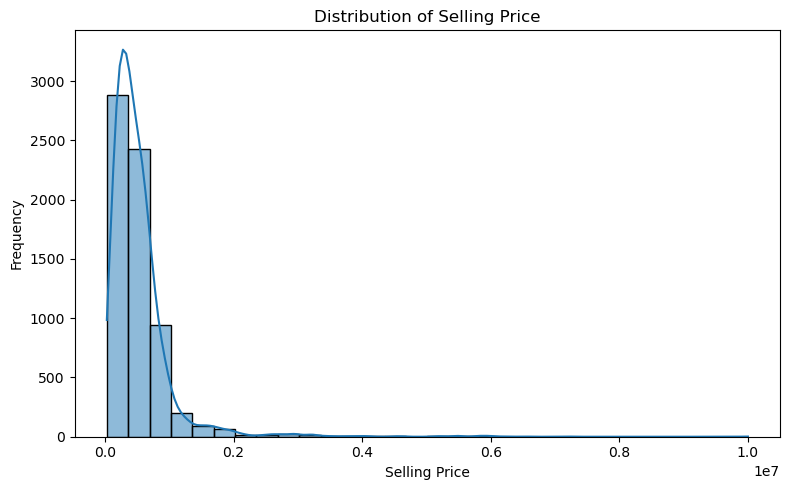

In [466]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(car_df['selling_price'], bins=30, kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Selling Price by Fuel Type

### This box plot compares the selling prices across different fuel types. It highlights the median price, price variation, and potential outliers for each category.

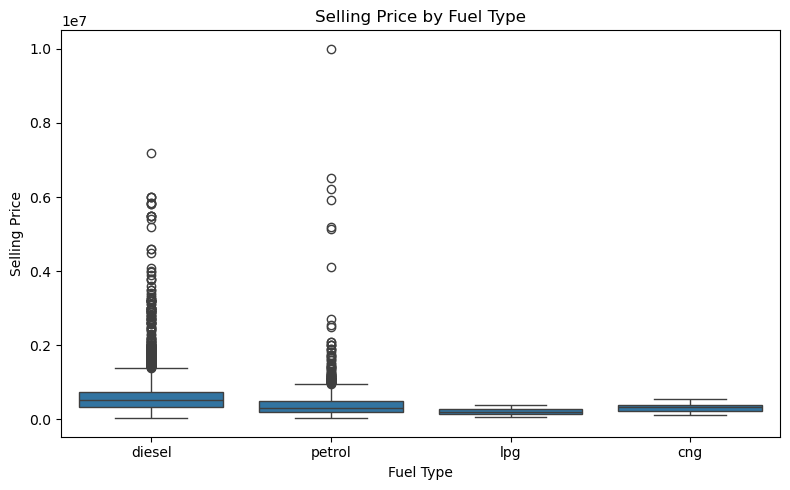

In [467]:
plt.figure(figsize=(8,5))
sns.boxplot(x='fuel', y='selling_price', data=car_df)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.tight_layout()
plt.show()

### Selling Price vs Car Age

### This scatter plot shows the relationship between car age and selling price. It helps identify whether older cars tend to have lower selling prices.

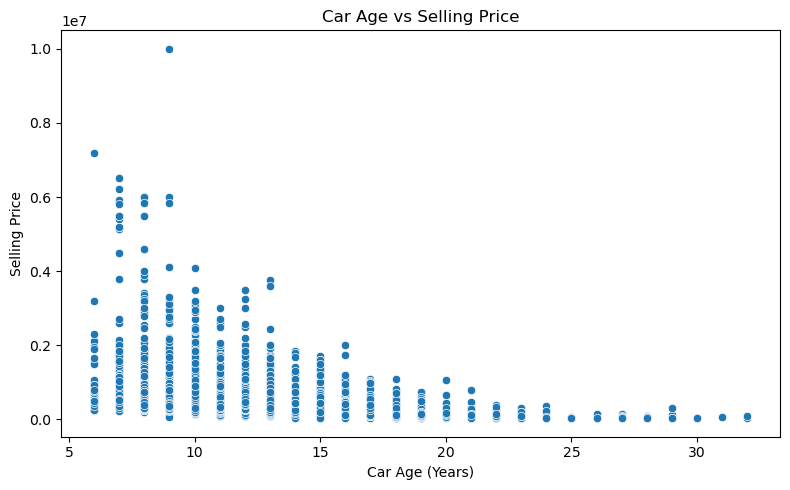

In [468]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='car_age', y='selling_price', data=car_df)

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")

plt.tight_layout()
plt.show()

In [469]:
# Encoding categorical variables using one-hot encoding
car_df_encoded = pd.get_dummies(car_df, columns=['fuel','seller_type','transmission','brand'], drop_first=True, dtype=int)
car_df_encoded

,name,year,selling_price,km_driven,owner,mileage,engine,max_power,torque,seats,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,Maruti Swift Dzire VDI,2014,450000,145500,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0,...,0,0,0,0,0,0,0,0,0,0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0,...,0,0,0,0,0,1,0,0,0,0
2,Honda City 2017-2020 EXi,2006,158000,140000,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0,...,0,0,0,0,0,0,0,0,0,0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0,...,0,0,0,0,0,0,0,0,0,0
4,Maruti Swift VXI BSIII,2007,130000,120000,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8121,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,Second Owner,18.9 kmpl,998 CC,67.1 bhp,90Nm@ 3500rpm,5.0,...,0,0,0,0,0,0,0,0,0,0
8122,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,Second Owner,22.54 kmpl,1396 CC,88.73 bhp,219.7Nm@ 1500-2750rpm,5.0,...,0,0,0,0,0,0,0,0,0,0
8123,Hyundai i20 Magna,2013,320000,110000,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0,...,0,0,0,0,0,0,0,0,0,0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0,...,0,0,0,0,0,0,0,0,0,0


In [470]:
car_df_encoded.dtypes

name                             object
year                              int64
selling_price                     int64
km_driven                         int64
owner                            object
mileage                          object
engine                           object
max_power                        object
torque                           object
seats                           float64
car_age                           int64
fuel_diesel                       int64
fuel_lpg                          int64
fuel_petrol                       int64
seller_type_Individual            int64
seller_type_Trustmark Dealer      int64
transmission_Manual               int64
brand_Ashok                       int64
brand_Audi                        int64
brand_BMW                         int64
brand_Chevrolet                   int64
brand_Daewoo                      int64
brand_Datsun                      int64
brand_Fiat                        int64
brand_Force                       int64


In [471]:
car_numeric_df = car_df_encoded.select_dtypes(include=['number'])
car_numeric_df

,year,selling_price,km_driven,seats,car_age,fuel_diesel,fuel_lpg,fuel_petrol,seller_type_Individual,seller_type_Trustmark Dealer,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,2014,450000,145500,5.0,12,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2014,370000,120000,5.0,12,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
2,2006,158000,140000,5.0,20,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,2010,225000,127000,5.0,16,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,2007,130000,120000,5.0,19,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8121,2013,260000,50000,5.0,13,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
8122,2014,475000,80000,5.0,12,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
8123,2013,320000,110000,5.0,13,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
8124,2007,135000,119000,5.0,19,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


## Correlation Heatmap

### The heatmap shows the correlation between numerical and encoded features. 
### It helps identify relationships among variables and detect highly correlated features that may affect model performance.

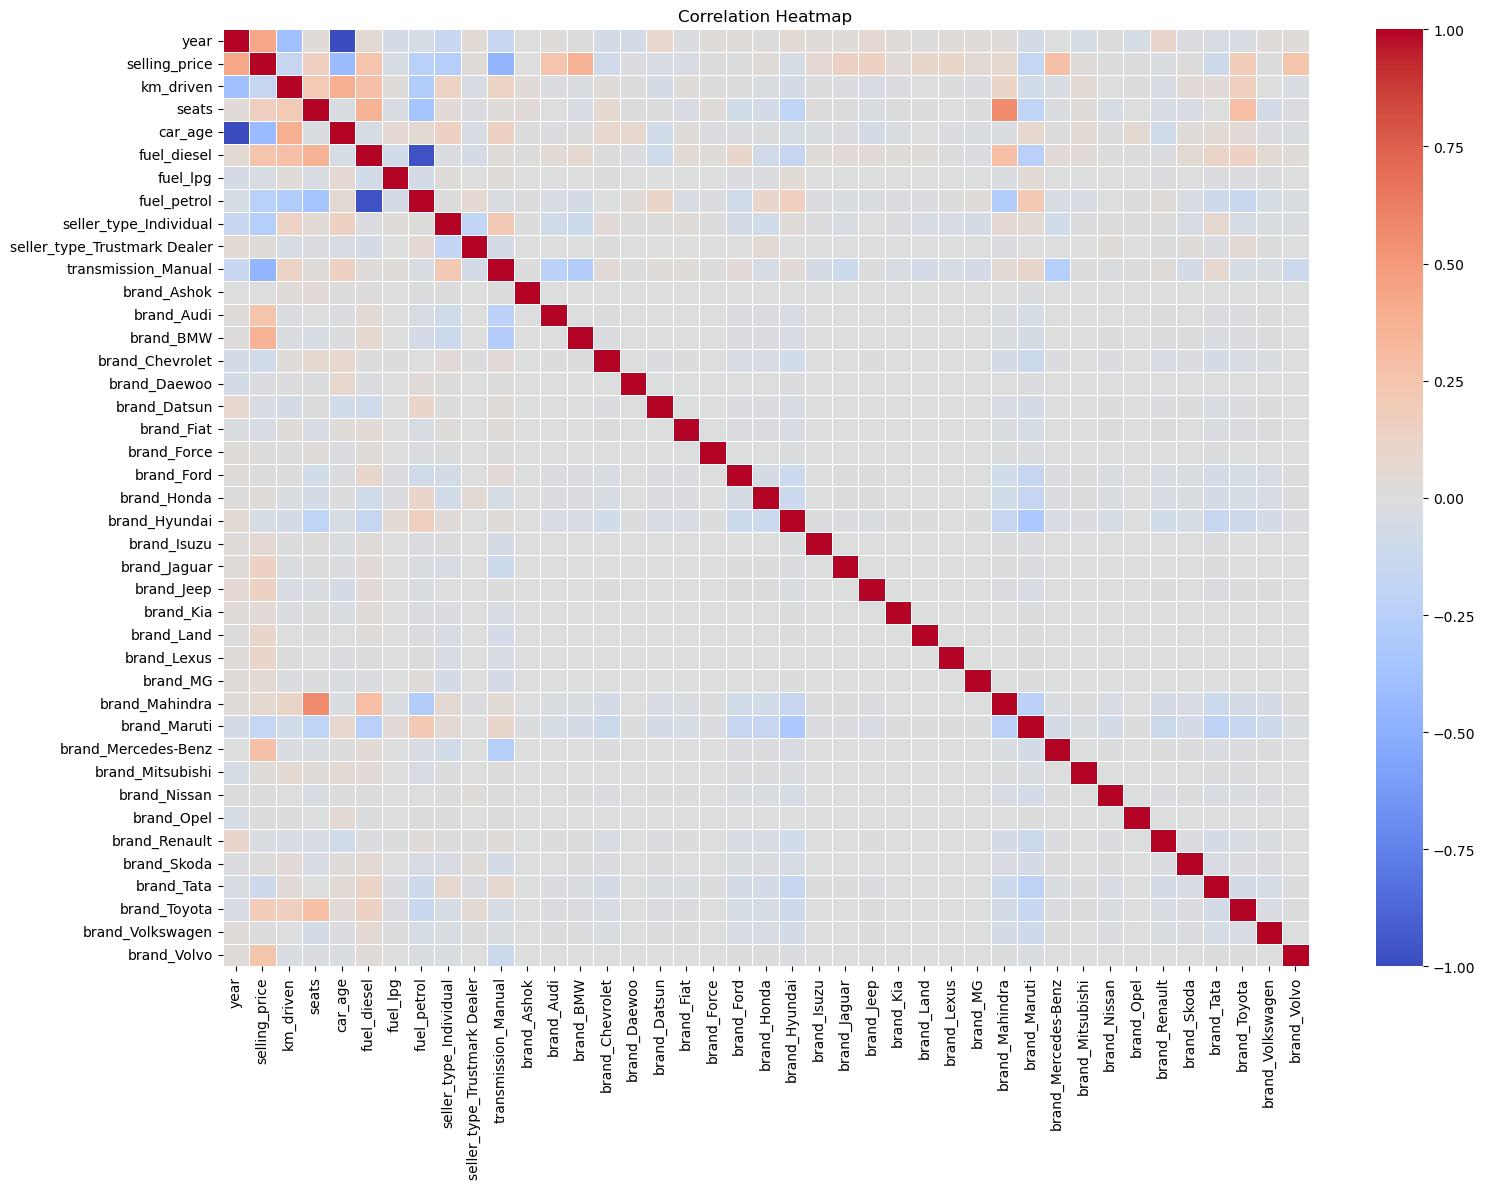

In [472]:
# Heatmap to visualize the correlation between numerical features
plt.figure(figsize=(16, 12))
sns.heatmap(car_numeric_df.corr(), cmap='coolwarm',linewidths=0.5)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [473]:
# Test Train Split 

X = car_numeric_df.drop('selling_price', axis=1)
y = car_numeric_df['selling_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [474]:
X_train 

,year,km_driven,seats,car_age,fuel_diesel,fuel_lpg,fuel_petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
2583,2014,80000,5.0,12,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
1428,2017,35000,5.0,9,1,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
7288,2013,64000,5.0,13,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6851,2018,25000,5.0,8,1,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4447,2013,90000,5.0,13,1,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4475,2011,40000,5.0,15,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
6224,2015,80000,7.0,11,1,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
6268,2019,14548,5.0,7,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
6450,2014,100000,5.0,12,1,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In [475]:
y_train

2583    426999
1428    700000
7288    650000
6851    720000
4447    409999
         ...  
4475    229999
6224    650000
6268    595000
6450    560000
941     280000
Name: selling_price, Length: 5373, dtype: int64

In [476]:
# Linear Model
Linear_model = LinearRegression()
Linear_model.fit(X_train, y_train)

LinearRegression()

In [477]:
y_pred_linear= Linear_model.predict(X_test)
y_pred_linear

array([643897.65373668, 665420.6565375 , 196262.40431353, ...,
       530949.81677825, 589983.14717151, 253284.0049601 ])

In [478]:
# Random Forest Model
random_model = RandomForestRegressor(n_estimators=100,random_state=42)
random_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [479]:
y_pred_random = random_model.predict(X_test)
y_pred_random

array([908309.84      , 686310.        , 220524.14666667, ...,
       456998.79380952, 802954.10714286, 244983.28333333])

In [480]:
# Evaluation Metrics for Linear Regression Model

linear_mae = mean_absolute_error(y_test, y_pred_linear)
print(f"Linear Regression MAE: {linear_mae}")

linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
print(f"Linear Regression RMSE: {linear_rmse}")

linear_r2 = r2_score(y_test, y_pred_linear)
print(f"Linear Regression R^2: {linear_r2}")

Linear Regression MAE: 155205.48471852476
Linear Regression RMSE: 260334.04736186579
Linear Regression R^2: 0.6911380535524709


In [481]:
# Evaluation Metrics for Random Forest Model
random_mae = mean_absolute_error(y_test, y_pred_random)
print(f"Random Forest MAE: {random_mae}")

random_rmse = np.sqrt(mean_squared_error(y_test, y_pred_random))
print(f"Random Forest RMSE: {random_rmse}")

random_r2 = r2_score(y_test, y_pred_random)
print(f"Random Forest R^2: {random_r2}")

Random Forest MAE: 122308.50084611664
Random Forest RMSE: 208422.58391803436
Random Forest R^2: 0.8020333586923554


In [482]:
# Comparison of the two models based on their evaluation metrics

comparison_df = pd.DataFrame({
    "Model" : ["Linear Regression", "Random Forest"],
    "Mean Absolute Error (MAE)" : [linear_mae, random_mae],
    "Root Mean Squared Error (RMSE)" : [linear_rmse, random_rmse],
    "R-Squared Score" : [linear_r2, random_r2]
})

comparison_df

,Model,Mean Absolute Error (MAE),Root Mean Squared Error (RMSE),R-Squared Score
0,Linear Regression,155205.484719,260334.047362,0.691138
1,Random Forest,122308.500846,208422.583918,0.802033


## Feature Importance

### Feature importance shows the contribution of each feature in predicting the selling price. Higher importance indicates a greater influence on the model's predictions.

In [483]:
# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': random_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
9,transmission_Manual,2.281271e-01
1,km_driven,1.224025e-01
0,year,1.117010e-01
3,car_age,1.040558e-01
4,fuel_diesel,5.905225e-02
39,brand_Volvo,5.020670e-02
2,seats,4.479707e-02
12,brand_BMW,4.301082e-02
6,fuel_petrol,3.780783e-02
11,brand_Audi,3.483527e-02


### Observation

#### The bar chart highlights the most influential features used by the Random Forest model for predicting car selling prices. Features with higher importance contribute more to the model's predictions, while features with lower importance have less impact.

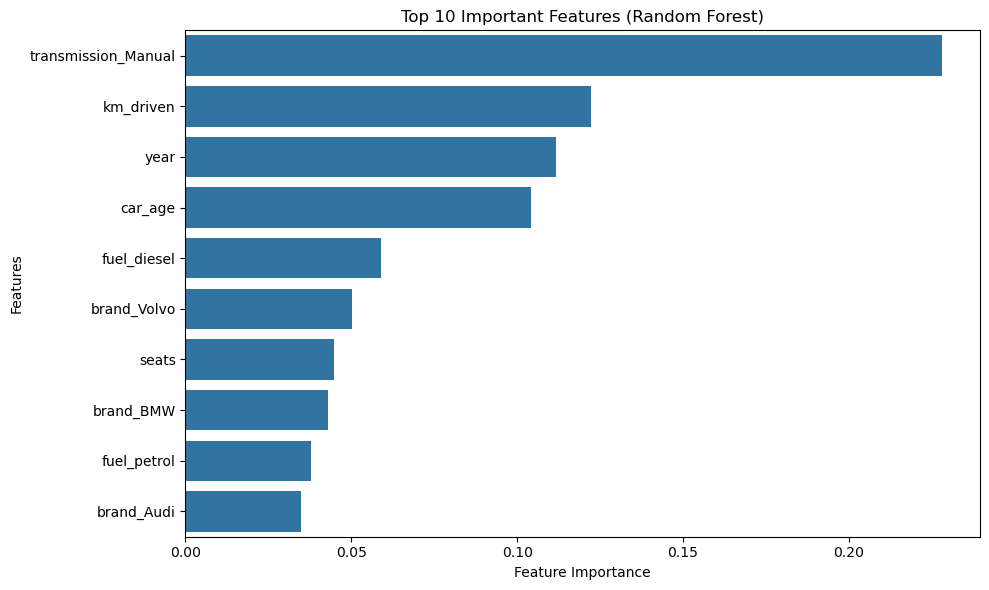

In [484]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## Conclusion

Two regression models were trained to predict the selling price of used cars.

- The **Linear Regression** model achieved an **R² Score of 0.6911**, explaining approximately **69.11%** of the variance in the selling price.
- The **Random Forest Regressor** outperformed the Linear Regression model with an **R² Score of 0.8020**, explaining approximately **80.20%** of the variance.
- The Random Forest model also achieved a lower **MAE (122,308.50)** and **RMSE (208,422.58)**, indicating more accurate predictions.

**Overall, the Random Forest Regressor was the best-performing model for this dataset and is the preferred model for predicting used car selling prices.**